In [20]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import awkward as ak
import sys
sys.path.append('../utils/')
import plotting_utils as pu

In [9]:
arrs = np.load('../checkpoints/of-development-runs/of_trial_2/weights/iteration_4_step_2.npz')
print(arrs.files)
file = uproot.open('/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_train_Mar1023.root')
tree = file['OmniTree']

['raw_train', 'raw_test', 'train', 'test']


In [14]:
start_weights = ak.to_numpy(tree['weight'].array())
end_weights = arrs['train']

In [15]:
delta_weights = end_weights / start_weights

/tmp/ipykernel_234837/42246191.py:1: RuntimeWarning: invalid value encountered in divide
  delta_weights = end_weights / start_weights


In [34]:
good_idx
cleaned_delta_weights = delta_weights[not np.isnan(delta_weights)]

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [26]:
raw_num_source = len(delta_weights)
effective = np.sum(delta_weights)**2 / np.sum(delta_weights**2)
loss_factor = effective / raw_num_source

In [33]:
print(np.isnan(delta_weights).nonzero())
print(np.sum(delta_weights**2))

(array([   4460,    5110,    5170, ..., 1424381, 1424457, 1424465]),)
nan


In [29]:
print(loss_factor)
print(raw_num_source)
print(effective)

nan
1424466
nan


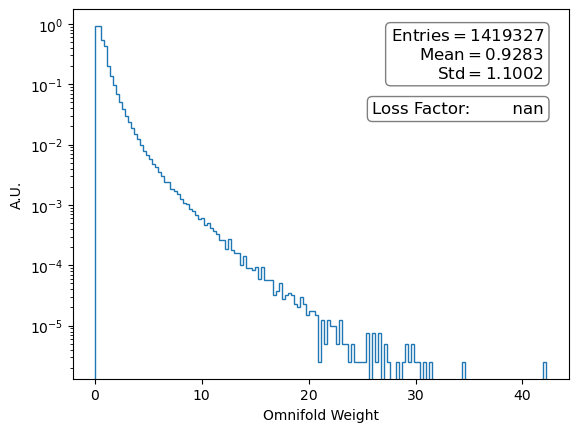

In [27]:
plt.hist(delta_weights, bins=150, histtype='step', density=True)
ax = plt.gca()
pu.add_stats_box(ax, delta_weights)
textstr = f'Loss Factor: {loss_factor:10.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
ax.text(0.95, 0.75, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='right', bbox=props)
plt.yscale('log')
plt.xlabel('Omnifold Weight')
plt.ylabel('A.U.')
plt.show()